In [ ]:
from google.colab import files
uploaded = files.upload()  # select Credit_modelling.csv


Saving Credit modelling.csv to Credit modelling (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [ ]:
import pandas as pd
df = pd.read_csv('Credit modelling.csv')
df.shape
df.dtypes
df.isnull().sum()
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637765,3629.136466,0.177019,679.25695,15129.300909,12.400627,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [ ]:
num_cols = ['age','annual_income','monthly_income','debt_to_income_ratio','credit_score',
            'loan_amount','interest_rate','loan_term','installment','num_of_open_accounts',
            'total_credit_limit','current_balance','delinquency_history','public_records',
            'num_of_delinquencies']

outlier_summary = {}
for c in num_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[c]<low)|(df[c]>high)).sum()
    outlier_summary[c] = (n_out, round(100*n_out/len(df),2))

pd.DataFrame(outlier_summary, index=['n_outliers','pct_outliers']).T


,n_outliers,pct_outliers
age,0.0,0.00
annual_income,924.0,4.62
monthly_income,924.0,4.62
debt_to_income_ratio,262.0,1.31
credit_score,74.0,0.37
loan_amount,76.0,0.38
interest_rate,141.0,0.70
loan_term,0.0,0.00
installment,150.0,0.75
num_of_open_accounts,283.0,1.42


In [ ]:
for col in ['annual_income','monthly_income','total_credit_limit','current_balance']:
    cap = df[col].quantile(0.99)
    df[col + '_capped'] = np.where(df[col] > cap, cap, df[col])

In [ ]:
cap = df['annual_income'].quantile(0.99)
df['annual_income_capped'] = np.where(df['annual_income']>cap, cap, df['annual_income'])

In [ ]:
desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
desc

,count,mean,std,min,25%,50%,75%,max,skew
age,20000.0,48.027000,15.829352,21.00,35.0000,48.000,62.0000,75.000,0.013828
annual_income,20000.0,43549.637765,28668.579671,6000.00,24260.7525,36585.260,54677.9175,400000.000,2.330753
monthly_income,20000.0,3629.136466,2389.048326,500.00,2021.7300,3048.770,4556.4950,33333.330,2.330753
debt_to_income_ratio,20000.0,0.177019,0.105059,0.01,0.0960,0.160,0.2410,0.667,0.787739
credit_score,20000.0,679.256950,69.638580,373.00,632.0000,680.000,727.0000,850.000,-0.070714
loan_amount,20000.0,15129.300909,8605.405513,500.00,8852.6950,14946.170,20998.8675,49039.690,0.253093
interest_rate,20000.0,12.400627,2.442729,3.14,10.7400,12.400,14.0025,22.510,0.027426
loan_term,20000.0,43.222800,11.008380,36.00,36.0000,36.000,60.0000,60.000,0.868007
installment,20000.0,455.625794,274.622125,9.43,253.9100,435.595,633.5950,1685.400,0.470715
num_of_open_accounts,20000.0,5.011800,2.244529,0.00,3.0000,5.000,6.0000,15.000,0.445643


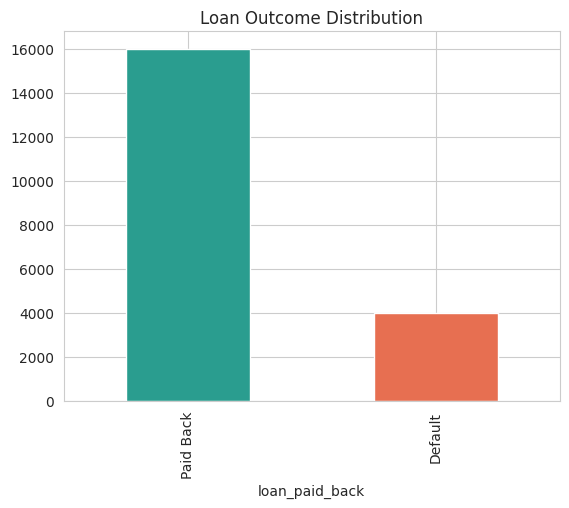

In [ ]:
df['loan_paid_back'].map({1:'Paid Back',0:'Default'}).value_counts().plot(kind='bar', color=['#2a9d8f','#e76f51'])
plt.title('Loan Outcome Distribution')
plt.show()

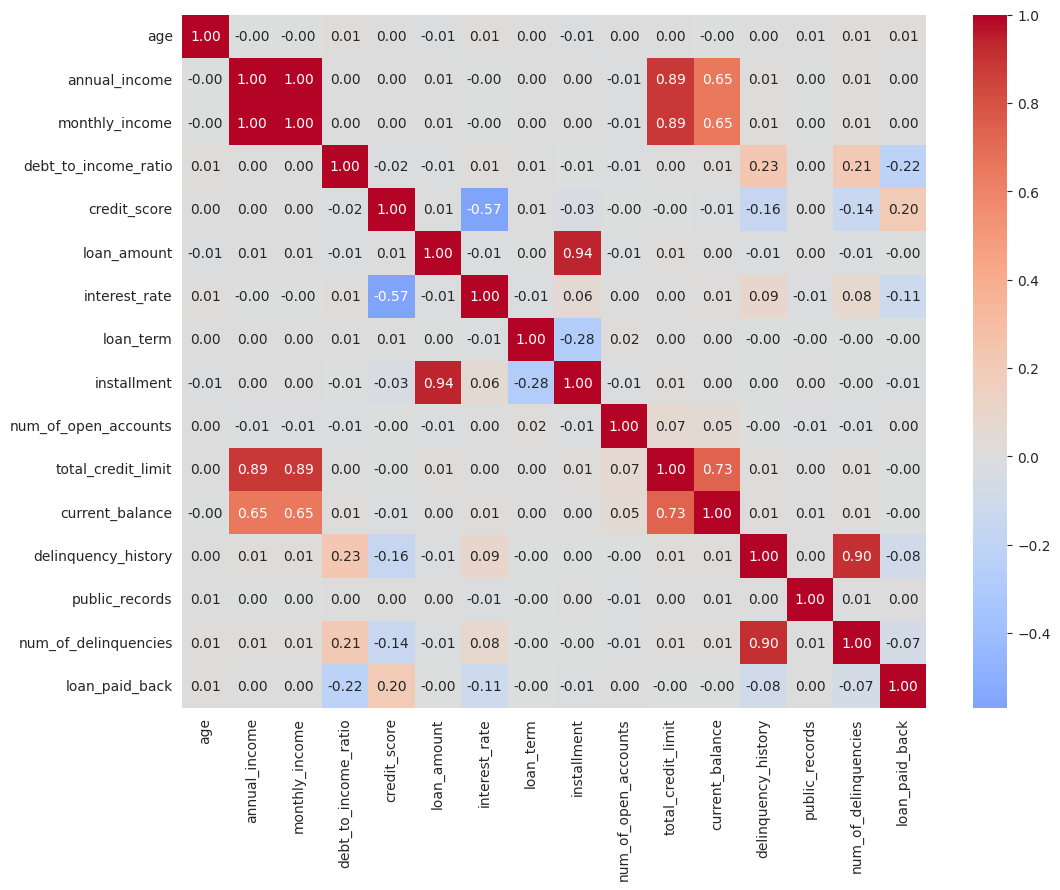

In [ ]:
plt.figure(figsize=(12,9))
corr = df[num_cols+['loan_paid_back']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()


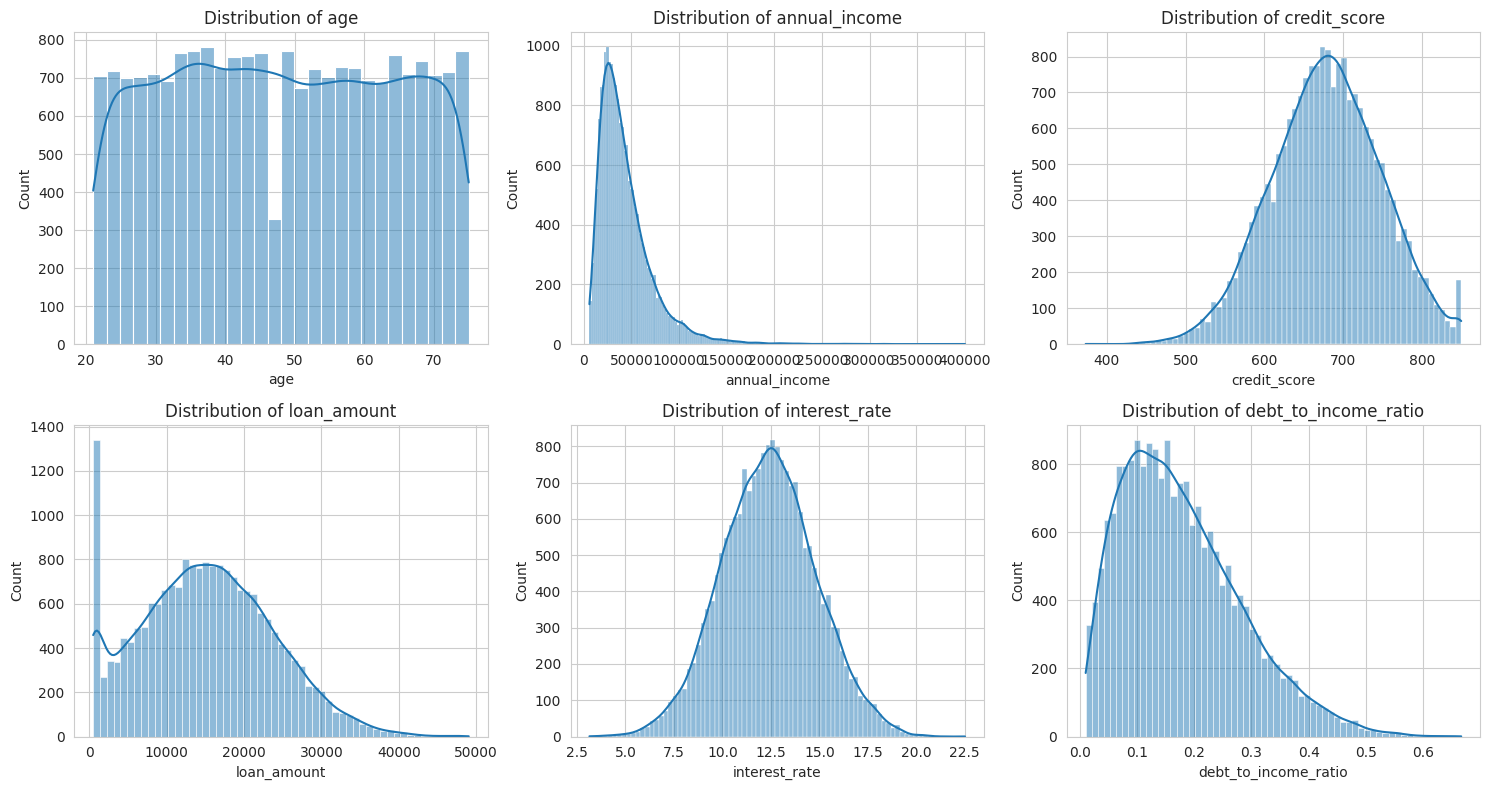

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax, c in zip(axes.flat, ['age','annual_income','credit_score','loan_amount','interest_rate','debt_to_income_ratio']):
    sns.histplot(df[c], kde=True, ax=ax)
    ax.set_title(f'Distribution of {c}')
plt.tight_layout(); plt.show()

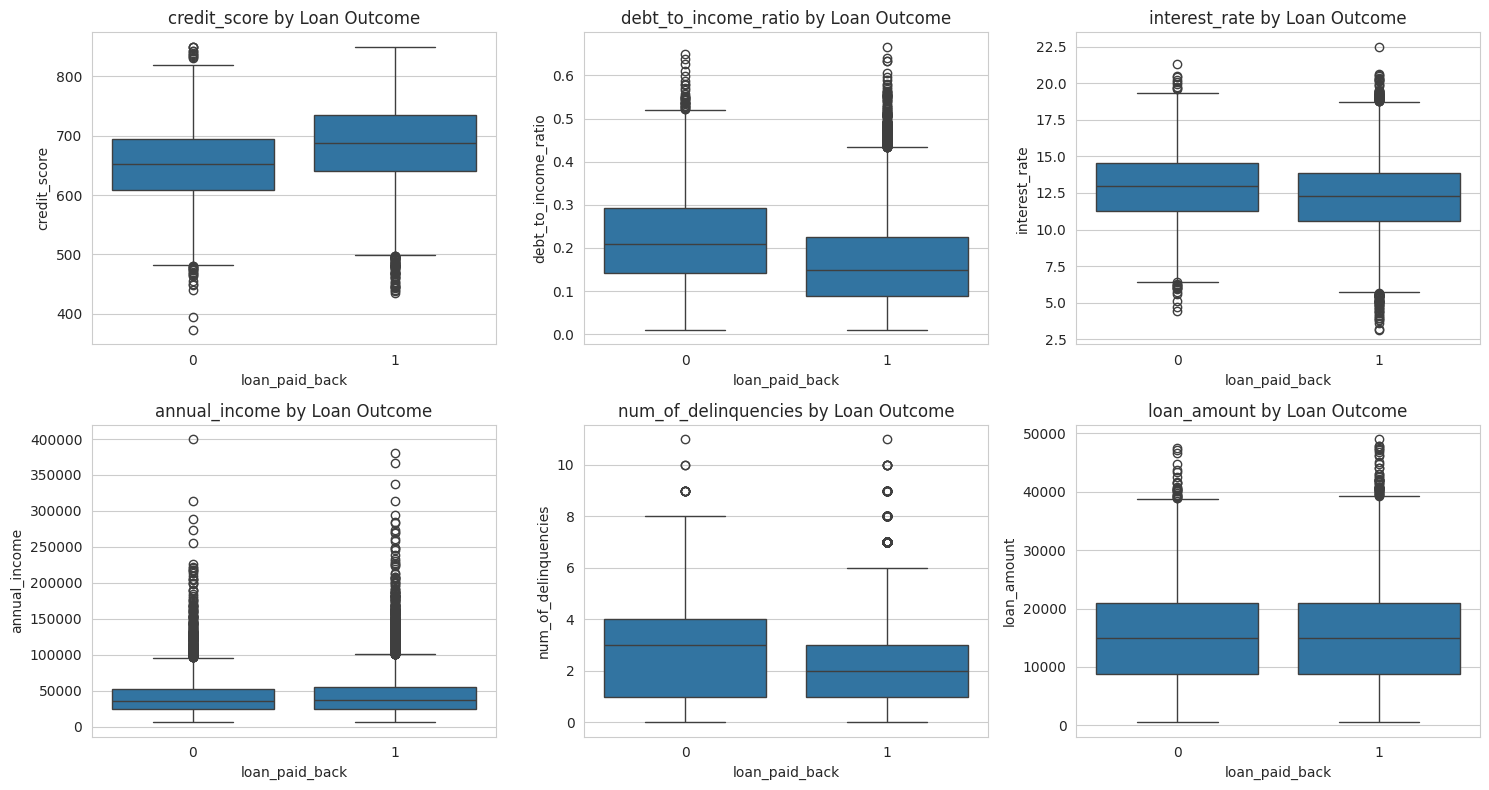

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax, c in zip(axes.flat, ['credit_score','debt_to_income_ratio','interest_rate','annual_income','num_of_delinquencies','loan_amount']):
    sns.boxplot(x='loan_paid_back', y=c, data=df, ax=ax)
    ax.set_title(f'{c} by Loan Outcome')
plt.tight_layout(); plt.show()


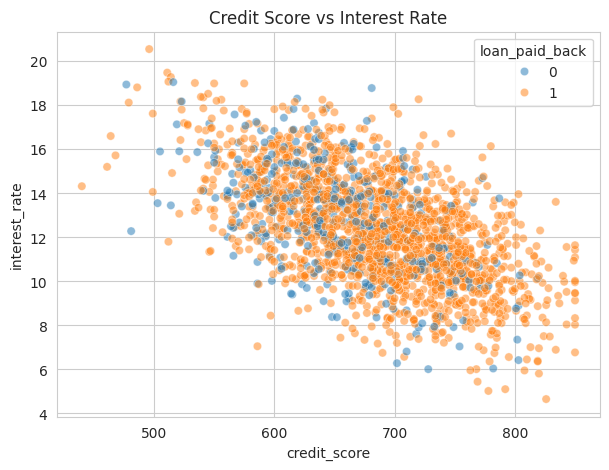

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='credit_score', y='interest_rate', hue='loan_paid_back', data=df.sample(2000, random_state=1), alpha=0.5)
plt.title('Credit Score vs Interest Rate')
plt.show()

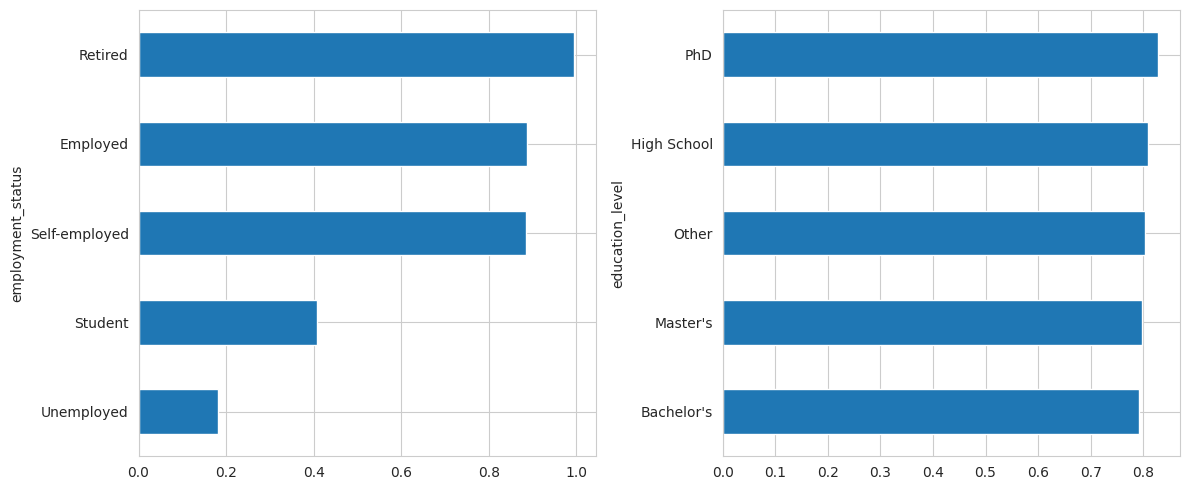

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
df.groupby('employment_status')['loan_paid_back'].mean().sort_values().plot(kind='barh', ax=axes[0])
df.groupby('education_level')['loan_paid_back'].mean().sort_values().plot(kind='barh', ax=axes[1])
plt.tight_layout(); plt.show()

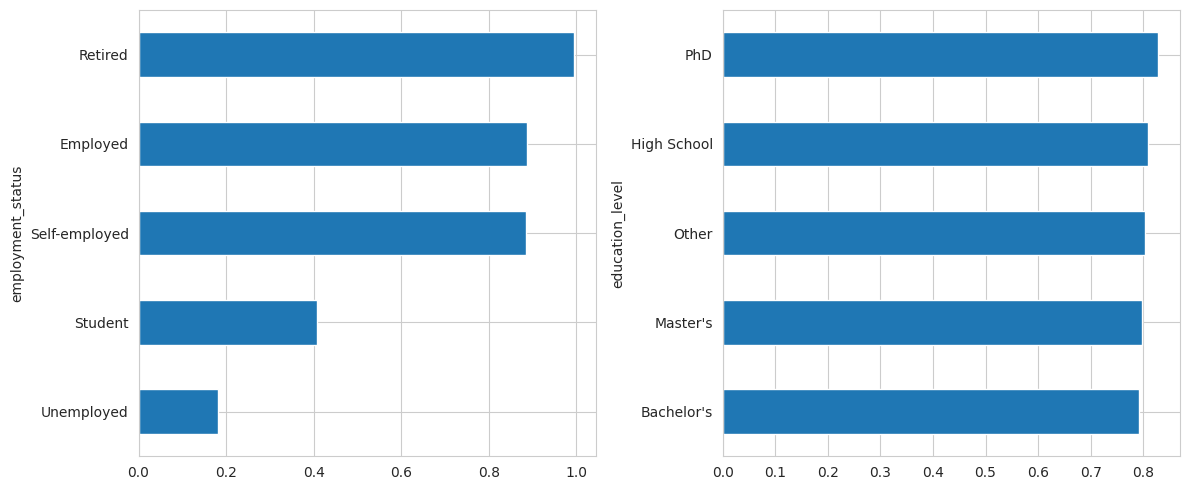

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
df.groupby('employment_status')['loan_paid_back'].mean().sort_values().plot(kind='barh', ax=axes[0])
df.groupby('education_level')['loan_paid_back'].mean().sort_values().plot(kind='barh', ax=axes[1])
plt.tight_layout(); plt.show()

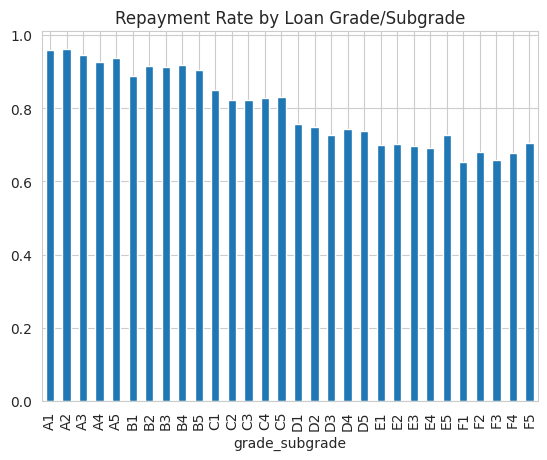

In [ ]:
grade_order = sorted(df['grade_subgrade'].unique())
df.groupby('grade_subgrade')['loan_paid_back'].mean().reindex(grade_order).plot(kind='bar')
plt.title('Repayment Rate by Loan Grade/Subgrade')
plt.show()

In [ ]:
df_enc = pd.get_dummies(df.drop(columns=['annual_income_capped','grade_subgrade']),
                         columns=['gender','marital_status','education_level','employment_status','loan_purpose'],
                         drop_first=True)

letters = {l:i for i,l in enumerate('ABCDEFG')}
df_enc['grade_score'] = df['grade_subgrade'].apply(lambda x: letters[x[0]]*5 + int(x[1]))

y = df_enc['loan_paid_back']
X = df_enc.drop(columns=['loan_paid_back'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_s, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

models = {
    'Logistic Regression': (log_reg.predict(X_test_s), log_reg.predict_proba(X_test_s)[:,1]),
    'Random Forest': (rf.predict(X_test), rf.predict_proba(X_test)[:,1]),
    'Decision Tree': (dt.predict(X_test), dt.predict_proba(X_test)[:,1])
}

results = {}
for name, (y_pred, y_prob) in models.items():
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.816000,0.926379,0.836424,0.879106,0.882938
Random Forest,0.860167,0.914747,0.909981,0.912358,0.882098
Decision Tree,0.850000,0.910507,0.901021,0.905739,0.869862


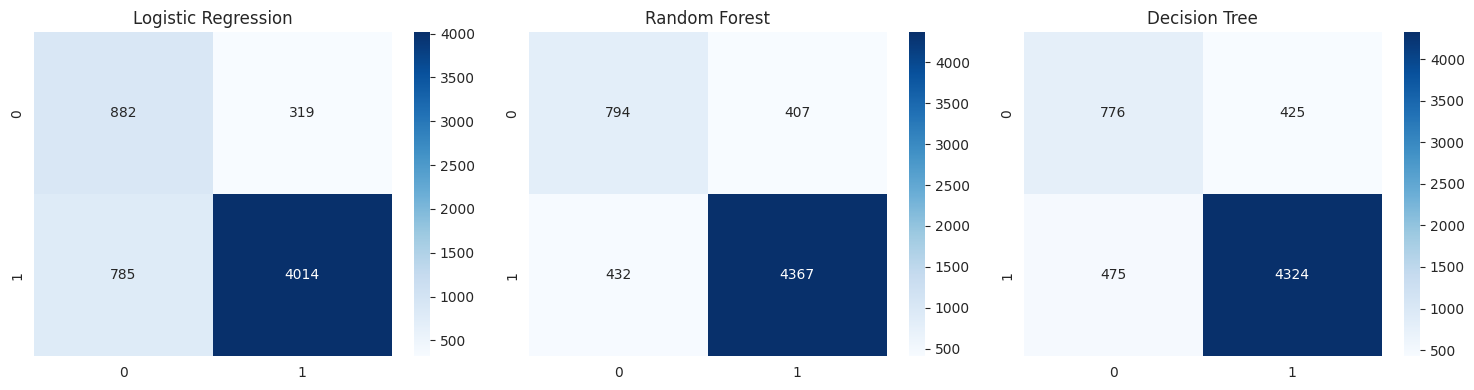

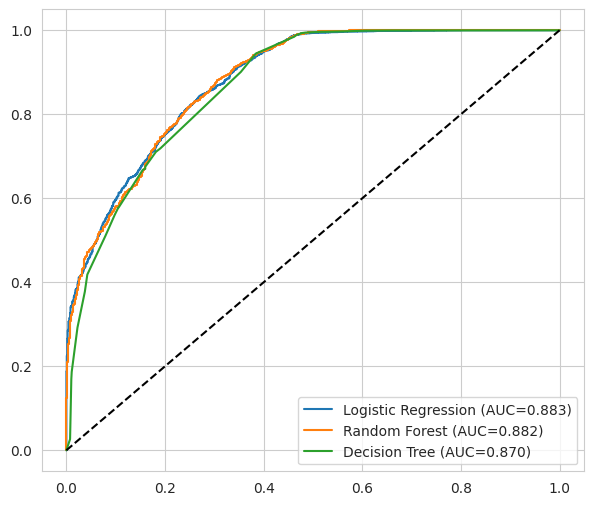

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,6))
for name, (_, y_prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.3f})')
plt.plot([0,1],[0,1],'k--')
plt.legend(); plt.show()

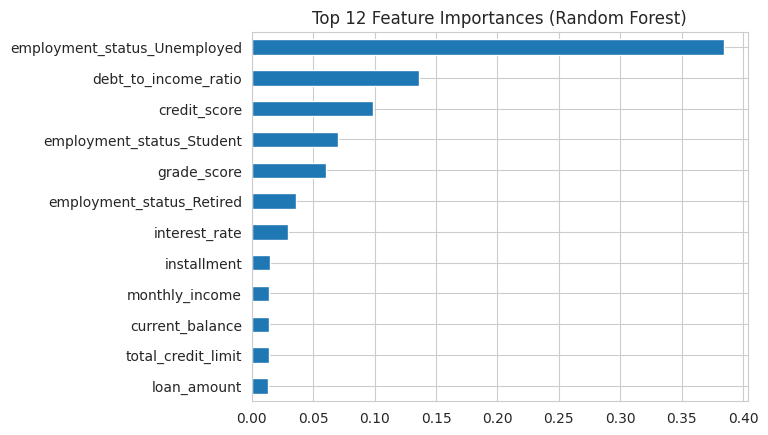

In [ ]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
fi.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 12 Feature Importances (Random Forest)')
plt.show()


In [ ]:
df.to_csv('cleaned_data.csv', index=False)
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X = df.drop('loan_paid_back', axis=1)
y = df['loan_paid_back']

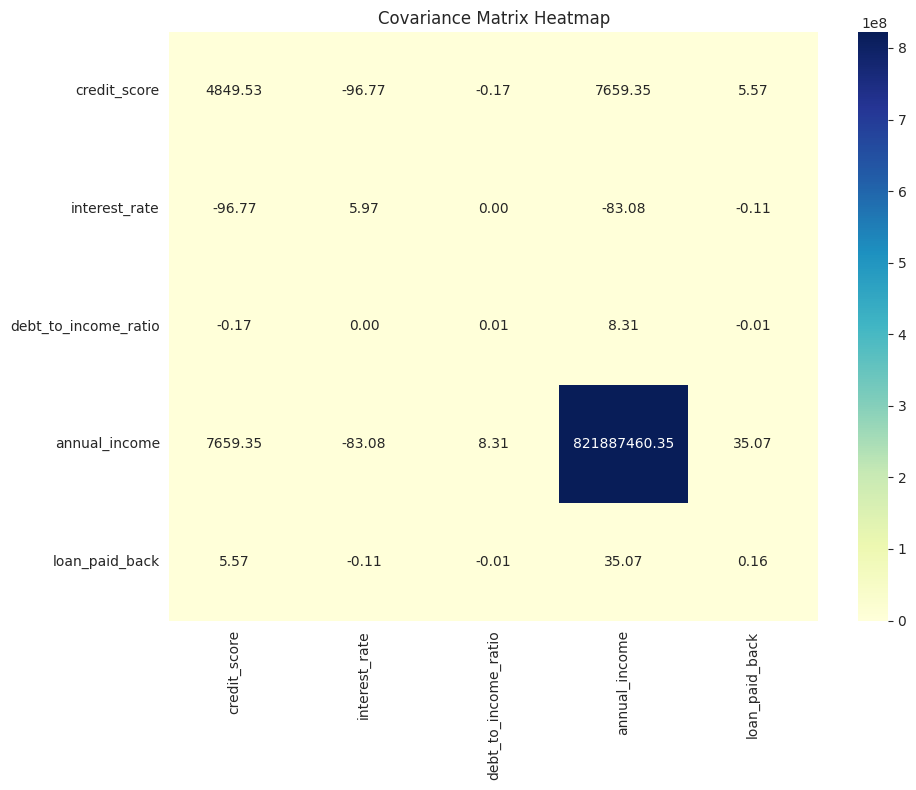

In [ ]:
plt.figure(figsize=(10,8))
cov_matrix = df[['credit_score','interest_rate','debt_to_income_ratio','annual_income','loan_paid_back']].cov()
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Covariance Matrix Heatmap')
plt.tight_layout()
plt.show()